In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid', context='notebook')

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'depmap_24Q4' / 'architecture' / 'model_master.csv').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repository.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA = PROJECT_ROOT / 'data' / 'depmap_24Q4'
PATHS = {
    'master': DATA / 'architecture' / 'model_master.csv',
    'conditions': DATA / 'derived' / 'model_condition_context.csv',
    'screen_qc': DATA / 'derived' / 'crispr_screen_qc_model.csv',
    'growth': DATA / 'raw' / 'CRISPRInferredModelGrowthRate.csv',
    'efficacy': DATA / 'raw' / 'CRISPRInferredModelEfficacy.csv',
}
for name, path in PATHS.items():
    print(f'{name}: {path}')

master: C:\Users\Avishek\Desktop\AZ_project_data\code\az-team25\data\depmap_24Q4\architecture\model_master.csv
conditions: C:\Users\Avishek\Desktop\AZ_project_data\code\az-team25\data\depmap_24Q4\derived\model_condition_context.csv
screen_qc: C:\Users\Avishek\Desktop\AZ_project_data\code\az-team25\data\depmap_24Q4\derived\crispr_screen_qc_model.csv
growth: C:\Users\Avishek\Desktop\AZ_project_data\code\az-team25\data\depmap_24Q4\raw\CRISPRInferredModelGrowthRate.csv
efficacy: C:\Users\Avishek\Desktop\AZ_project_data\code\az-team25\data\depmap_24Q4\raw\CRISPRInferredModelEfficacy.csv


In [2]:
master = pd.read_csv(PATHS['master'], low_memory=False)
conditions = pd.read_csv(PATHS['conditions'], low_memory=False)
screen_qc = pd.read_csv(PATHS['screen_qc'], low_memory=False)
growth_wide = pd.read_csv(PATHS['growth'], low_memory=False)
efficacy_wide = pd.read_csv(PATHS['efficacy'], low_memory=False)

for name, frame in {
    'model_master': master, 'model_condition_context': conditions,
    'crispr_screen_qc_model': screen_qc, 'growth_rate': growth_wide, 'efficacy': efficacy_wide,
}.items():
    print(f'{name}: {frame.shape[0]:,} rows x {frame.shape[1]:,} columns')

display(conditions.head(3))
display(screen_qc.head(3))

model_master: 2,105 rows x 42 columns
model_condition_context: 2,764 rows x 16 columns
crispr_screen_qc_model: 1,401 rows x 23 columns
growth_rate: 1,178 rows x 4 columns
efficacy: 1,178 rows x 4 columns


,model_id,ModelConditionID,ParentModelConditionID,DataSource,CellFormat,Morphology,PassageNumber,GrowthMedia,FormulationID,PlateCoating,SerumFreeMedia,PrescreenTreatmentDrug,PrescreenTreatmentDrugDays,AnchorDrug,AnchorDrugConcentration,AnchorDaysWithDrug
0,ACH-000001,MC-000001-ztiA,NaN,BROAD,adherent,NaN,NaN,MF-001-041,RPMI + 20% FBS + 0.01 mg/ml insulin,NaN,False,NaN,NaN,NaN,NaN,NaN
1,ACH-000001,MC-000001-ZU8p,NaN,SANGER,adherent,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ACH-000002,MC-000002-8QnY,NaN,BROAD,suspension,NaN,NaN,MF-005-001,IMDM + 10% FBS,NaN,False,NaN,NaN,NaN,NaN,NaN


,model_id,ScreenID,ScreenNotBlacklisted,ScreenPermissionToRelease,ScreenNNMD,ScreenROCAUC,ScreenFPR,ScreenMedianEssentialDepletion,ScreenMedianNonessentialDepletion,ScreenMADEssentials,ScreenMADNonessentials,PassesQC,CanInclude,QCStatus,HasCopyNumber,ModelConditionID,ModelID,Library,ScreenType,CasActivity,ScreenDoublingTime,nPassingSequences,nIncludedSequences
0,ACH-001041,SC-001041.AV01,True,True,-8.097676,0.975128,0.023448,-0.800118,0.021010,0.270125,0.101403,True,True,PASS,True,MC-001041-CkXW,ACH-001041,Avana,2DS,61.8,50.0,2,2
1,ACH-001737,SC-001737.AV01,True,True,-2.582032,0.820941,0.040000,-0.224458,0.003493,0.158436,0.088284,True,True,PASS,True,MC-001737-6D5K,ACH-001737,Avana,2DS,67.1,40.0,2,2
2,ACH-000921,SC-000921.AV01,True,True,-9.280182,0.985395,0.019310,-1.148742,-0.006933,0.303171,0.123037,True,True,PASS,True,MC-000921-P628,ACH-000921,Avana,2DS,92.8,31.0,2,2


In [4]:
master_ids = set(master['model_id'])
coverage_audit = pd.DataFrame([
    {'table': 'model_condition_context', 'rows': len(conditions), 'unique_models': conditions['model_id'].nunique(), 'models_not_in_master': len(set(conditions['model_id']) - master_ids)},
    {'table': 'crispr_screen_qc_model', 'rows': len(screen_qc), 'unique_models': screen_qc['model_id'].nunique(), 'models_not_in_master': len(set(screen_qc['model_id']) - master_ids)},
    {'table': 'growth_rate', 'rows': len(growth_wide), 'unique_models': growth_wide['ModelID'].nunique(), 'models_not_in_master': len(set(growth_wide['ModelID']) - master_ids)},
    {'table': 'efficacy', 'rows': len(efficacy_wide), 'unique_models': efficacy_wide['ModelID'].nunique(), 'models_not_in_master': len(set(efficacy_wide['ModelID']) - master_ids)},
])
coverage_audit['pct_of_master'] = (100 * coverage_audit['unique_models'] / len(master)).round(2)
display(coverage_audit)

assert conditions['ModelConditionID'].is_unique
assert screen_qc['ScreenID'].is_unique
assert growth_wide['ModelID'].is_unique
assert efficacy_wide['ModelID'].is_unique
assert not (set(screen_qc['model_id']) - master_ids)
print('PASS: primary condition/screen keys are unique and all CRISPR-context model IDs map to model_master.')

,table,rows,unique_models,models_not_in_master,pct_of_master
0,model_condition_context,2764,2009,0,95.44
1,crispr_screen_qc_model,1401,1178,0,55.96
2,growth_rate,1178,1178,0,55.96
3,efficacy,1178,1178,0,55.96


PASS: primary condition/screen keys are unique and all CRISPR-context model IDs map to model_master.


,n_conditions
count,2009.000000
mean,1.375809
std,0.488546
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,3.000000


,conditions_per_model,models
0,1,1258
1,2,747
2,3,4


,missing_n,missing_pct,unique_non_null
ParentModelConditionID,2764,100.00,0
Morphology,2764,100.00,0
PlateCoating,2764,100.00,0
PrescreenTreatmentDrug,2764,100.00,0
PrescreenTreatmentDrugDays,2764,100.00,0
AnchorDrug,2764,100.00,0
AnchorDrugConcentration,2764,100.00,0
AnchorDaysWithDrug,2764,100.00,0
PassageNumber,2713,98.15,3
GrowthMedia,1194,43.20,159


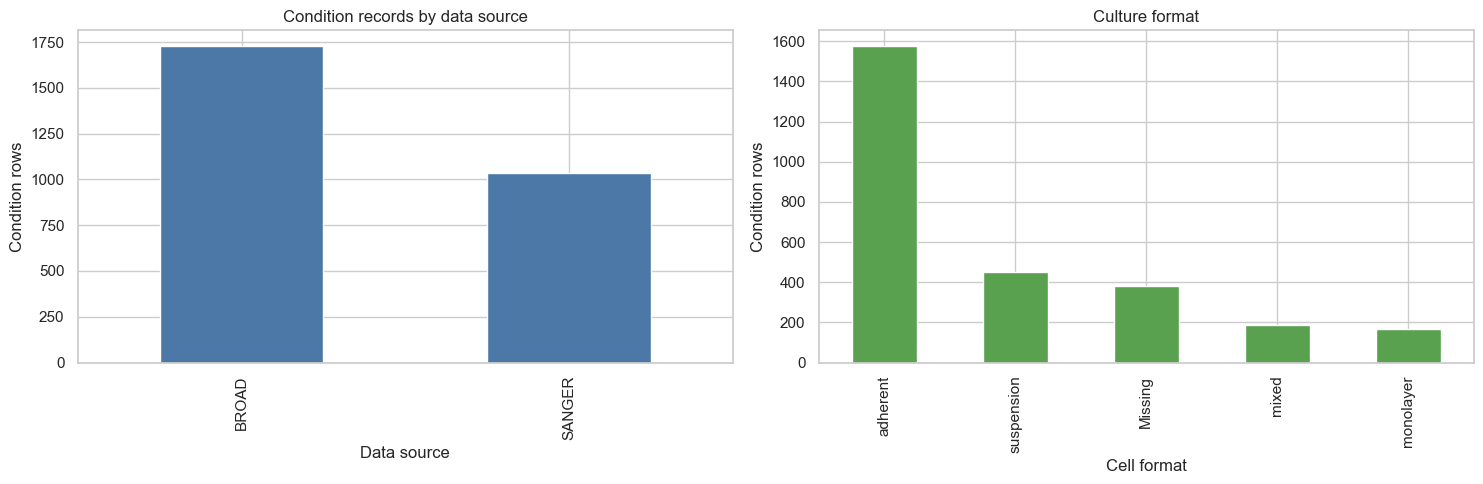

#### Missingness by condition-data source (%)

DataSource,BROAD,SANGER
model_id,0.0,0.0
ModelConditionID,0.0,0.0
ParentModelConditionID,100.0,100.0
CellFormat,2.7,32.4
Morphology,100.0,100.0
PassageNumber,97.0,100.0
GrowthMedia,9.2,99.9
FormulationID,9.2,99.9
PlateCoating,100.0,100.0
SerumFreeMedia,9.2,99.9


#### Most common growth-media identifiers

,GrowthMedia,condition_rows
0,Missing,1194
1,MF-001-001,552
2,MF-002-001,194
3,MF-001-020,83
4,MF-006-001,62
5,MF-001-005,38
6,MF-001-003,36
7,MF-001-014,31
8,MF-023-001,24
9,MF-004-001,22


In [ ]:
condition_counts = conditions.groupby('model_id').size().rename('n_conditions')
display(condition_counts.describe().to_frame())
display(condition_counts.value_counts().sort_index().rename_axis('conditions_per_model').reset_index(name='models'))

condition_missingness = pd.DataFrame({
    'missing_n': conditions.isna().sum(),
    'missing_pct': (100 * conditions.isna().mean()).round(2),
    'unique_non_null': conditions.nunique(dropna=True),
}).sort_values('missing_pct', ascending=False)
display(condition_missingness)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
conditions['DataSource'].value_counts().plot.bar(ax=axes[0], color='#4C78A8', title='Condition records by data source')
axes[0].set_xlabel('Data source'); axes[0].set_ylabel('Condition rows')
conditions['CellFormat'].fillna('Missing').value_counts().plot.bar(ax=axes[1], color='#59A14F', title='Culture format')
axes[1].set_xlabel('Cell format'); axes[1].set_ylabel('Condition rows')
plt.tight_layout(); plt.show()

source_missingness = conditions.groupby('DataSource').apply(lambda frame: frame.isna().mean().mul(100), include_groups=False).T
display(Markdown('#### Missingness by condition-data source (%)'))
display(source_missingness.round(1))

media_counts = conditions['GrowthMedia'].fillna('Missing').value_counts().head(20).rename_axis('GrowthMedia').reset_index(name='condition_rows')
display(Markdown('#### Most common growth-media identifiers'))
display(media_counts)

,column,value_counts
0,ScreenNotBlacklisted,{True: 1401}
1,ScreenPermissionToRelease,{True: 1401}
2,PassesQC,{True: 1401}
3,CanInclude,{True: 1401}
4,QCStatus,{'PASS': 1401}
5,HasCopyNumber,{True: 1401}


,n_screens
count,1178.000000
mean,1.189304
std,0.406808
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,3.000000


,screens_per_model,models
0,1,962
1,2,209
2,3,7


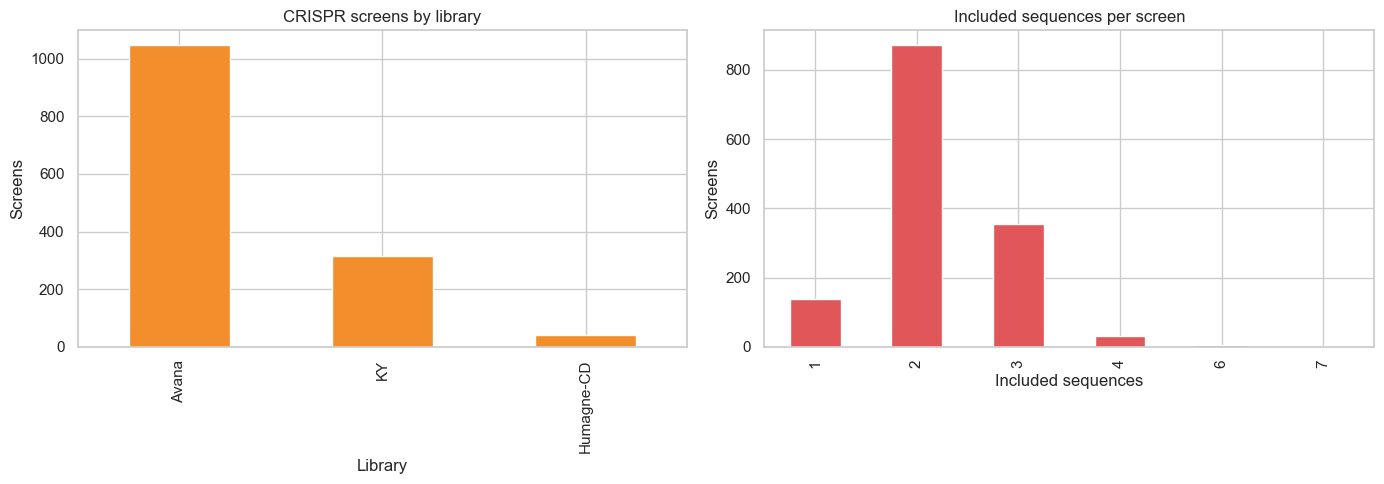

,count,mean,std,min,25%,50%,75%,max
ScreenNNMD,1401.0,-7.454306,2.902425,-17.319611,-9.317984,-7.216327,-5.313818,-1.275920
ScreenROCAUC,1401.0,0.943177,0.042517,0.702246,0.928293,0.955507,0.971868,0.992145
ScreenFPR,1401.0,0.047752,0.018523,0.013793,0.034483,0.045161,0.057931,0.201379
ScreenMedianEssentialDepletion,1401.0,-1.231902,0.584083,-4.126564,-1.605508,-1.190023,-0.815158,-0.056772
ScreenMedianNonessentialDepletion,1401.0,0.005796,0.029716,-0.238312,-0.007672,0.007810,0.023646,0.116874
ScreenMADEssentials,1401.0,0.545624,0.275313,0.085875,0.319745,0.520183,0.738751,1.585898
ScreenMADNonessentials,1401.0,0.167223,0.065672,0.066767,0.125747,0.155322,0.193493,0.932235
CasActivity,1073.0,75.523868,15.394878,10.000000,65.000000,79.800000,88.300000,99.600000
ScreenDoublingTime,1043.0,60.704794,38.700456,20.000000,40.000000,52.000000,72.000000,938.000000


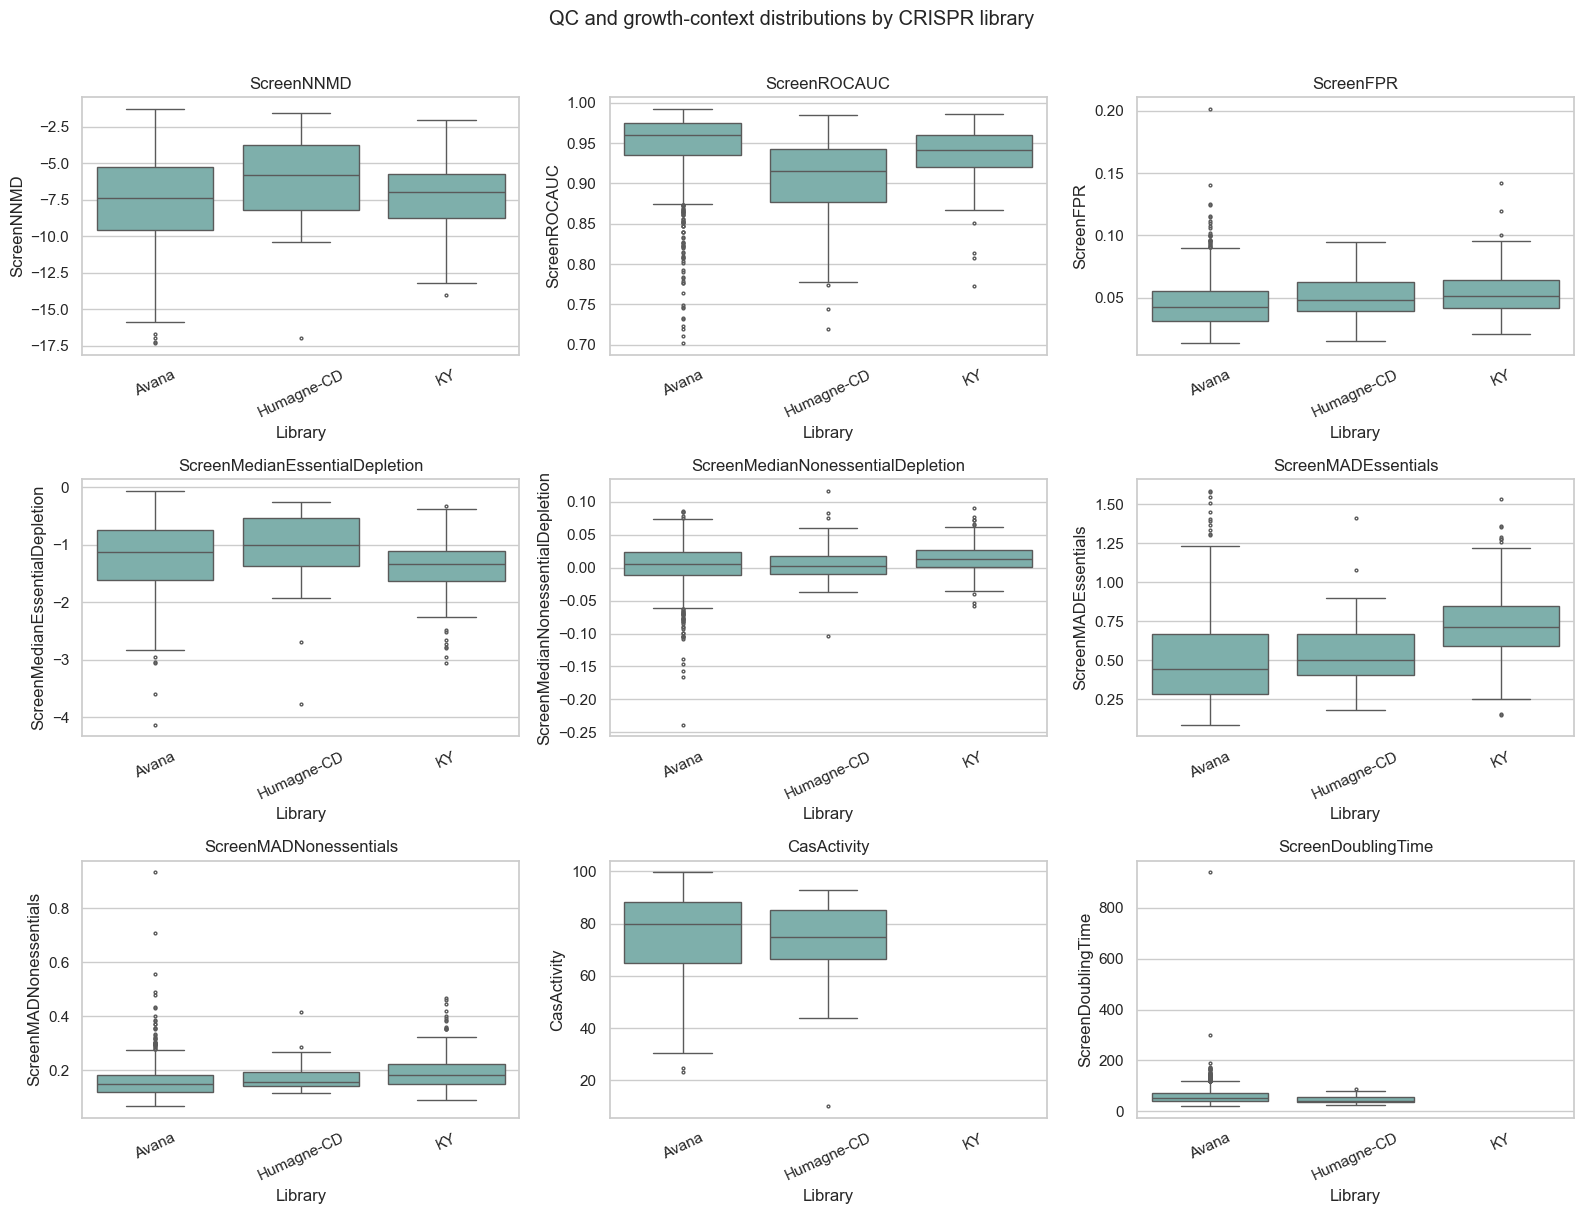

In [6]:
qc_flag_columns = ['ScreenNotBlacklisted', 'ScreenPermissionToRelease', 'PassesQC', 'CanInclude', 'QCStatus', 'HasCopyNumber']
qc_flags = pd.DataFrame({
    'column': qc_flag_columns,
    'value_counts': [screen_qc[c].value_counts(dropna=False).to_dict() for c in qc_flag_columns],
})
display(qc_flags)

screen_counts = screen_qc.groupby('model_id').size().rename('n_screens')
display(screen_counts.describe().to_frame())
display(screen_counts.value_counts().sort_index().rename_axis('screens_per_model').reset_index(name='models'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
screen_qc['Library'].value_counts().plot.bar(ax=axes[0], color='#F28E2B', title='CRISPR screens by library')
axes[0].set_xlabel('Library'); axes[0].set_ylabel('Screens')
screen_qc['nIncludedSequences'].value_counts().sort_index().plot.bar(ax=axes[1], color='#E15759', title='Included sequences per screen')
axes[1].set_xlabel('Included sequences'); axes[1].set_ylabel('Screens')
plt.tight_layout(); plt.show()

qc_metrics = ['ScreenNNMD', 'ScreenROCAUC', 'ScreenFPR', 'ScreenMedianEssentialDepletion', 'ScreenMedianNonessentialDepletion', 'ScreenMADEssentials', 'ScreenMADNonessentials', 'CasActivity', 'ScreenDoublingTime']
display(screen_qc[qc_metrics].describe().T)

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, metric in zip(axes.flat, qc_metrics):
    sns.boxplot(data=screen_qc, x='Library', y=metric, ax=ax, color='#76B7B2', fliersize=2)
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=25)
plt.suptitle('QC and growth-context distributions by CRISPR library', y=1.01)
plt.tight_layout(); plt.show()

In [7]:
# Robust, library-specific review flags. These are investigation prompts, not automatic exclusions.
review_metrics = ['ScreenNNMD', 'ScreenROCAUC', 'ScreenFPR', 'CasActivity', 'ScreenDoublingTime']
screen_qc = screen_qc.copy()
for metric in review_metrics:
    q1 = screen_qc.groupby('Library')[metric].transform(lambda x: x.quantile(0.25))
    q3 = screen_qc.groupby('Library')[metric].transform(lambda x: x.quantile(0.75))
    iqr = q3 - q1
    screen_qc[f'{metric}_iqr_review'] = (screen_qc[metric] < q1 - 1.5 * iqr) | (screen_qc[metric] > q3 + 1.5 * iqr)

review_flags = [f'{metric}_iqr_review' for metric in review_metrics]
screen_qc['n_numeric_review_flags'] = screen_qc[review_flags].sum(axis=1)
review_summary = screen_qc['n_numeric_review_flags'].value_counts().sort_index().rename_axis('numeric_review_flags').reset_index(name='screens')
display(review_summary)

review_queue = screen_qc.loc[screen_qc['n_numeric_review_flags'].gt(0), ['model_id', 'ScreenID', 'Library', *qc_metrics, 'n_numeric_review_flags']].sort_values(['n_numeric_review_flags', 'ScreenFPR'], ascending=[False, False])
display(Markdown('#### Screens for review before relying on an unusual dependency result'))
display(review_queue.head(50))

,numeric_review_flags,screens
0,0,1268
1,1,103
2,2,28
3,3,2


#### Screens for review before relying on an unusual dependency result

,model_id,ScreenID,Library,ScreenNNMD,ScreenROCAUC,ScreenFPR,ScreenMedianEssentialDepletion,ScreenMedianNonessentialDepletion,ScreenMADEssentials,ScreenMADNonessentials,CasActivity,ScreenDoublingTime,n_numeric_review_flags
756,ACH-001454,SC-001454.AV01,Avana,-2.959278,0.852180,0.115862,-1.125146,-0.026966,0.593716,0.371097,88.5,120.0,3
728,ACH-001396,SC-001396.AV01,Avana,-3.019833,0.819422,0.092414,-0.482574,-0.024869,0.372832,0.151566,85.4,120.0,3
281,ACH-000459,SC-000459.AV01,Avana,-1.713345,0.720155,0.201379,-0.234724,-0.019158,0.272446,0.125816,45.2,78.0,2
1121,ACH-000350,SC-000350.KY01,KY,-2.025492,0.773156,0.141935,-0.384070,0.029424,0.355559,0.204145,NaN,NaN,2
422,ACH-000672,SC-000672.AV01,Avana,-1.278770,0.723293,0.140690,-0.153306,-0.004257,0.120371,0.116556,67.9,100.0,2
555,ACH-000878,SC-000878.AV01,Avana,-2.562893,0.860655,0.125517,-0.610820,-0.031880,0.240450,0.225893,88.1,50.0,2
204,ACH-000338,SC-000338.AV01,Avana,-1.455758,0.710927,0.124138,-0.966853,-0.156868,0.681850,0.556402,89.6,30.0,2
1186,ACH-000878,SC-000878.KY01,KY,-2.262871,0.807401,0.119355,-0.807881,0.061311,0.626749,0.384110,NaN,NaN,2
352,ACH-000557,SC-000557.AV01,Avana,-5.902833,0.866273,0.114483,-1.126950,0.032266,0.837972,0.196383,90.5,78.0,2
731,ACH-001401,SC-001401.AV02,Avana,-2.115015,0.810118,0.110345,-0.266120,-0.049485,0.132888,0.102427,58.6,48.0,2


Duplicate model-library QC rows: 3


inferred_growth_rate                           \
                          count    median mean       std   
Library                                                    
Avana                      1043  0.991529  1.0  0.196334   
Humagne-CD                   40  0.986567  1.0  0.098648   
KY                          315  1.001410  1.0  0.150876   

           inferred_crispr_efficacy                                
                              count    median      mean       std  
Library                                                            
Avana                          1043  0.800282  0.754528  0.184547  
Humagne-CD                       40  0.795336  0.755039  0.166002  
KY                              315  0.920575  0.900049  0.077752

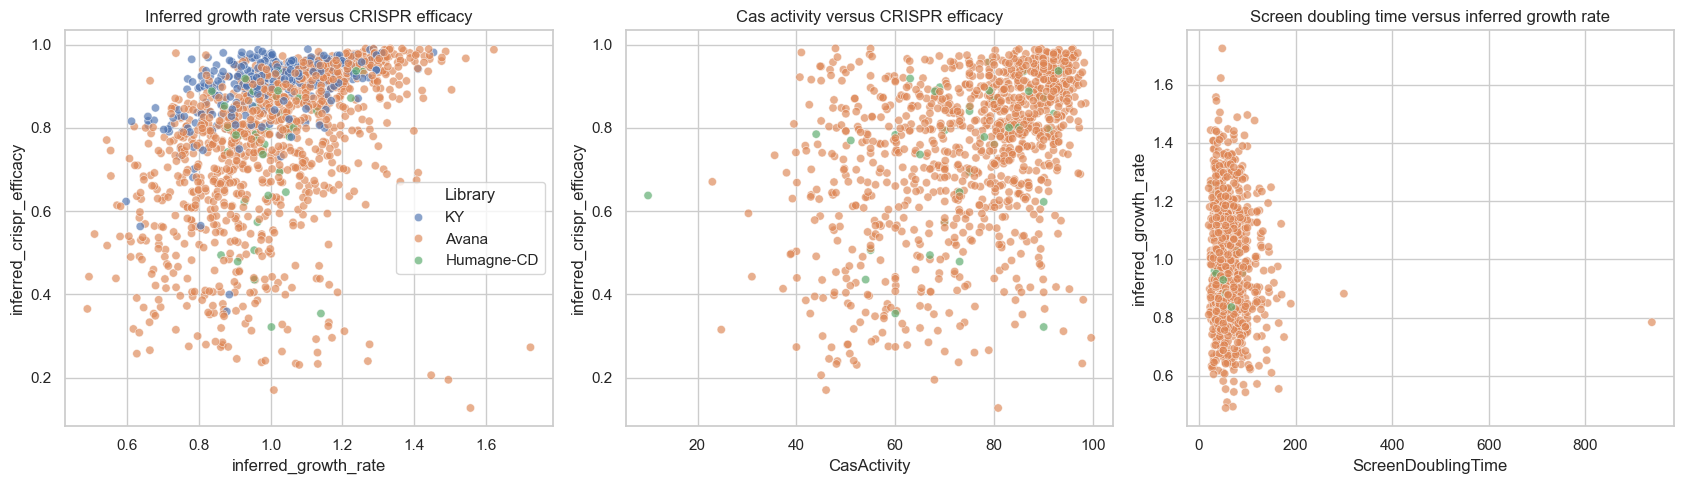

#### Spearman correlations, calculated within library

**Avana** (n=1,043)

,inferred_growth_rate,inferred_crispr_efficacy,CasActivity,ScreenDoublingTime,ScreenROCAUC,ScreenFPR,ScreenNNMD
inferred_growth_rate,1.00,0.56,0.42,-0.10,0.51,-0.21,-0.50
inferred_crispr_efficacy,0.56,1.00,0.43,-0.02,0.49,-0.35,-0.74
CasActivity,0.42,0.43,1.00,-0.04,0.29,-0.06,-0.39
ScreenDoublingTime,-0.10,-0.02,-0.04,1.00,-0.29,0.24,0.13
ScreenROCAUC,0.51,0.49,0.29,-0.29,1.00,-0.78,-0.82
ScreenFPR,-0.21,-0.35,-0.06,0.24,-0.78,1.00,0.62
ScreenNNMD,-0.50,-0.74,-0.39,0.13,-0.82,0.62,1.00


**Humagne-CD** (n=40)

,inferred_growth_rate,inferred_crispr_efficacy,CasActivity,ScreenDoublingTime,ScreenROCAUC,ScreenFPR,ScreenNNMD
inferred_growth_rate,1.00,0.28,0.31,-0.41,0.45,-0.28,-0.37
inferred_crispr_efficacy,0.28,1.00,0.39,-0.31,0.69,-0.59,-0.84
CasActivity,0.31,0.39,1.00,-0.23,0.35,-0.26,-0.31
ScreenDoublingTime,-0.41,-0.31,-0.23,1.00,-0.48,0.53,0.42
ScreenROCAUC,0.45,0.69,0.35,-0.48,1.00,-0.85,-0.86
ScreenFPR,-0.28,-0.59,-0.26,0.53,-0.85,1.00,0.79
ScreenNNMD,-0.37,-0.84,-0.31,0.42,-0.86,0.79,1.00


**KY** (n=315)

,inferred_growth_rate,inferred_crispr_efficacy,CasActivity,ScreenDoublingTime,ScreenROCAUC,ScreenFPR,ScreenNNMD
inferred_growth_rate,1.00,0.51,NaN,NaN,0.77,-0.44,-0.68
inferred_crispr_efficacy,0.51,1.00,NaN,NaN,0.45,-0.09,-0.47
CasActivity,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ScreenDoublingTime,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ScreenROCAUC,0.77,0.45,NaN,NaN,1.00,-0.73,-0.87
ScreenFPR,-0.44,-0.09,NaN,NaN,-0.73,1.00,0.70
ScreenNNMD,-0.68,-0.47,NaN,NaN,-0.87,0.70,1.00


In [8]:
library_lookup = {
    'Achilles-Avana-2D': 'Avana',
    'Achilles-Humagne-CD-2D': 'Humagne-CD',
    'Achilles-KY-2D': 'KY',
}

growth_long = growth_wide.melt(id_vars='ModelID', var_name='growth_source', value_name='inferred_growth_rate').dropna()
growth_long['Library'] = growth_long['growth_source'].map(library_lookup)
efficacy_long = efficacy_wide.melt(id_vars='ModelID', var_name='efficacy_source', value_name='inferred_crispr_efficacy').dropna()
efficacy_long['Library'] = efficacy_long['efficacy_source'].map(library_lookup)

growth_efficacy = growth_long.merge(efficacy_long[['ModelID', 'Library', 'inferred_crispr_efficacy']], on=['ModelID', 'Library'], how='outer', validate='one_to_one')
growth_efficacy = growth_efficacy.rename(columns={'ModelID': 'model_id'})
screen_library_duplicates = screen_qc.duplicated(['model_id', 'Library']).sum()
print(f'Duplicate model-library QC rows: {screen_library_duplicates}')

qc_for_growth = (
    screen_qc.groupby(['model_id', 'Library'], as_index=False)
    .agg(
        n_matching_screens=('ScreenID', 'nunique'),
        CasActivity=('CasActivity', 'median'),
        ScreenDoublingTime=('ScreenDoublingTime', 'median'),
        ScreenROCAUC=('ScreenROCAUC', 'median'),
        ScreenFPR=('ScreenFPR', 'median'),
        ScreenNNMD=('ScreenNNMD', 'median'),
    )
)
growth_efficacy_qc = growth_efficacy.merge(qc_for_growth, on=['model_id', 'Library'], how='left', validate='one_to_one')
display(growth_efficacy_qc.groupby('Library')[['inferred_growth_rate', 'inferred_crispr_efficacy']].agg(['count', 'median', 'mean', 'std']))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
sns.scatterplot(data=growth_efficacy_qc, x='inferred_growth_rate', y='inferred_crispr_efficacy', hue='Library', alpha=0.65, ax=axes[0])
axes[0].set_title('Inferred growth rate versus CRISPR efficacy')
sns.scatterplot(data=growth_efficacy_qc, x='CasActivity', y='inferred_crispr_efficacy', hue='Library', alpha=0.65, ax=axes[1], legend=False)
axes[1].set_title('Cas activity versus CRISPR efficacy')
sns.scatterplot(data=growth_efficacy_qc, x='ScreenDoublingTime', y='inferred_growth_rate', hue='Library', alpha=0.65, ax=axes[2], legend=False)
axes[2].set_title('Screen doubling time versus inferred growth rate')
plt.tight_layout(); plt.show()

correlation_columns = ['inferred_growth_rate', 'inferred_crispr_efficacy', 'CasActivity', 'ScreenDoublingTime', 'ScreenROCAUC', 'ScreenFPR', 'ScreenNNMD']
display(Markdown('#### Spearman correlations, calculated within library'))
for library, frame in growth_efficacy_qc.groupby('Library'):
    display(Markdown(f'**{library}** (n={len(frame):,})'))
    display(frame[correlation_columns].corr(method='spearman').round(2))

In [9]:
qc_model_summary = (
    screen_qc.groupby('model_id')
    .agg(
        n_crispr_screens=('ScreenID', 'nunique'),
        libraries=('Library', lambda x: ' | '.join(sorted(set(x)))),
        max_numeric_review_flags=('n_numeric_review_flags', 'max'),
        median_cas_activity=('CasActivity', 'median'),
        median_screen_doubling_time=('ScreenDoublingTime', 'median'),
    )
    .reset_index()
)
condition_model_summary = conditions.groupby('model_id').agg(n_conditions=('ModelConditionID', 'nunique'), n_condition_sources=('DataSource', 'nunique')).reset_index()

model_context = (
    master[['model_id', 'oncotree_lineage', 'eligible_codependency_route', 'eligible_conditional_dependency_route', 'has_model_condition', 'has_crispr_screen_qc', 'has_crispr_efficacy', 'has_crispr_growth_rate']]
    .merge(condition_model_summary, on='model_id', how='left')
    .merge(qc_model_summary, on='model_id', how='left')
)
model_context['context_qc_available'] = model_context[['has_model_condition', 'has_crispr_screen_qc', 'has_crispr_efficacy', 'has_crispr_growth_rate']].eq(1).all(axis=1)

lineage_context = model_context.groupby('oncotree_lineage', dropna=False).agg(
    models=('model_id', 'size'),
    codependency_eligible=('eligible_codependency_route', 'sum'),
    conditional_dependency_eligible=('eligible_conditional_dependency_route', 'sum'),
    full_context_qc_available=('context_qc_available', 'sum'),
).sort_values('models', ascending=False)
for column in ['codependency_eligible', 'conditional_dependency_eligible', 'full_context_qc_available']:
    lineage_context[f'{column}_pct'] = (100 * lineage_context[column] / lineage_context['models']).round(1)
display(lineage_context)

eligible_models = model_context.loc[model_context['eligible_codependency_route'].eq(1)]
n_full_context = int(eligible_models['context_qc_available'].sum())
display(Markdown(f'### {len(eligible_models):,} models are eligible for codependency; {n_full_context:,} have all four context/QC/growth/efficacy flags.'))

review_model_queue = model_context.loc[(model_context['eligible_codependency_route'].eq(1)) & (model_context['max_numeric_review_flags'].fillna(0).gt(0)), ['model_id', 'oncotree_lineage', 'n_crispr_screens', 'libraries', 'max_numeric_review_flags', 'median_cas_activity', 'median_screen_doubling_time']]
display(Markdown('#### Eligible models with at least one numeric QC review flag'))
display(review_model_queue.sort_values('max_numeric_review_flags', ascending=False).head(50))

,models,codependency_eligible,conditional_dependency_eligible,full_context_qc_available,codependency_eligible_pct,conditional_dependency_eligible_pct,full_context_qc_available_pct
oncotree_lineage,,,,,,,
Lung,260,126,126,126,48.5,48.5,48.5
Lymphoid,260,93,93,93,35.8,35.8,35.8
Skin,149,74,74,74,49.7,49.7,49.7
CNS/Brain,125,90,90,90,72.0,72.0,72.0
Esophagus/Stomach,103,69,69,69,67.0,67.0,67.0
Bowel,99,63,63,63,63.6,63.6,63.6
Breast,96,53,53,53,55.2,55.2,55.2
Head and Neck,95,77,77,77,81.1,81.1,81.1
Bone,90,46,46,46,51.1,51.1,51.1


### 1,178 models are eligible for codependency; 1,178 have all four context/QC/growth/efficacy flags.

#### Eligible models with at least one numeric QC review flag

,model_id,oncotree_lineage,n_crispr_screens,libraries,max_numeric_review_flags,median_cas_activity,median_screen_doubling_time
1220,ACH-001396,Breast,1.0,Avana,3.0,85.40,120.0
1264,ACH-001454,Bowel,1.0,Avana,3.0,88.50,120.0
1576,ACH-002077,Lung,1.0,Avana,2.0,60.00,300.0
515,ACH-000519,Lymphoid,1.0,Avana,2.0,76.00,30.0
348,ACH-000350,Bowel,2.0,Avana | KY,2.0,89.30,96.0
1225,ACH-001401,Adrenal Gland,2.0,Avana | Humagne-CD,2.0,65.80,48.0
394,ACH-000396,Bladder/Urinary Tract,1.0,Avana,2.0,72.80,100.0
336,ACH-000338,Lymphoid,1.0,Avana,2.0,89.60,30.0
627,ACH-000631,CNS/Brain,1.0,Avana,2.0,50.40,78.0
1216,ACH-001392,Breast,1.0,Avana,2.0,40.00,120.0
